In [1]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz2"
NOBJ = 5
K = 10
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [2]:
MU = 1000
NGEN = 300
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [3]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz2, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [4]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        pop_comp = pop[:(int)(MU/(1 << NOBJ))]
        hv_val = hypervolume(pop_comp, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        approx_front_comp = approx_front[:(int)(MU/(1 << NOBJ))]
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front_comp)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [5]:
pop, logbook = main()

gen	evals	std                                                     	min                                                                          	avg                                                     	max                                                     	hypervolume	igd_plus
0  	1000 	[0.34511173 0.34574547 0.45427278 0.55363061 0.58742189]	[5.99149885e-06 9.11065343e-06 1.67745456e-05 6.34473063e-04
 9.22643418e-04]	[0.29176323 0.30792514 0.46286243 0.70974352 1.18329356]	[1.84871092 1.66929536 2.13889628 2.20723783 2.55921464]	           	        
1  	1000 	[0.409415   0.39769253 0.50286318 0.554403   0.50906883]	[5.99149885e-06 9.11065343e-06 1.67745456e-05 3.67380392e-04
 8.56725090e-04]	[0.35586371 0.36068001 0.54283948 0.73025518 0.85918394]	[2.09886192 1.66929536 2.21284716 2.09242121 2.14163764]	0.0354181  	0.722531
2  	1000 	[0.4576293  0.40958248 0.49109574 0.51710226 0.46102969]	[4.00965546e-07 1.00831864e-07 1.67745456e-05 3.59534616e-04
 8.50147917e-04]	[0.4335091  0.3

[0.4334198068900032, 0.1176137042896927, 0.6772444417153063, 0.8398821722815908, 0.4631605751509728, 0.5146445461561433, 0.5315836238877348, 0.5009399708153653, 0.40712620876008776, 0.5209761624728113, 0.2645599105043556, 0.5514795654706436, 0.5056857341653331, 0.5450835186564219]
[0.08911081362820186, 0.5194288797178697, 0.18397861293931925, 0.13124395263698188, 0.4516033948322971, 0.5253159864687882, 0.47347615913277785, 0.4865168687550146, 0.5175957111164035, 0.5492848040552547, 0.5189779899425452, 0.4877003536242299, 0.4920066719507786, 0.5389464035531891]
[0.0008577838312332497, 0.09995309937577834, 0.004876145569672585, 0.011107692348722817, 0.512394910649967, 0.47271943564904345, 0.4534949788418343, 0.49796619736909814, 0.4111715697512062, 0.5368076280090176, 0.46489948745771914, 0.48503180832262105, 0.49518200974414817, 0.527809665803691]
[0.16803716224215348, 0.07442659556838249, 0.7781220715712316, 0.9888538634193265, 0.5536135012463291, 0.46294801791996143, 0.487758114994121

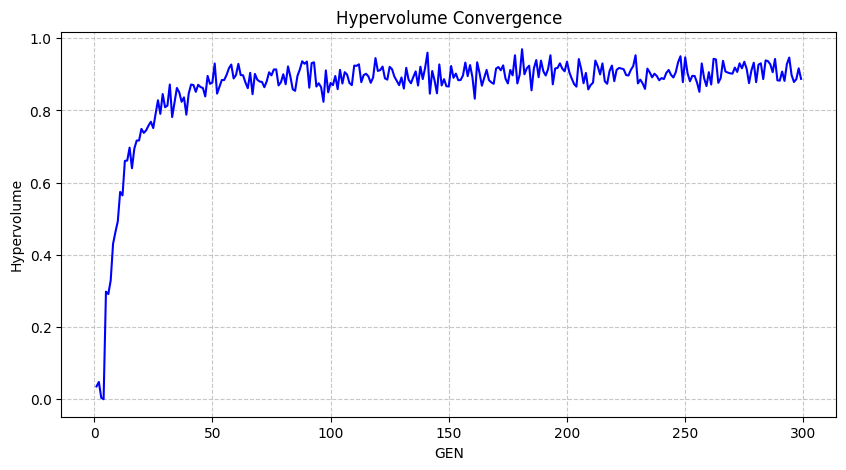

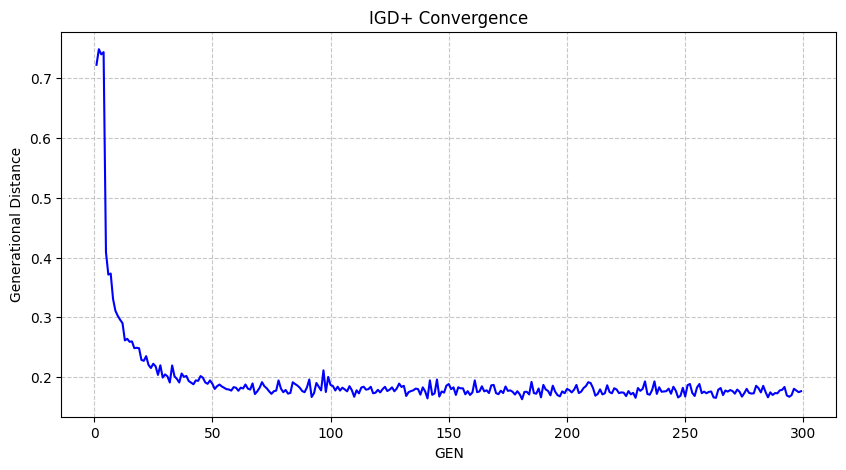

In [6]:
import matplotlib.pyplot as plt


for ind in pop:
   print(ind)

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()